# State Estimation: using LogChol-CaDeLaC for inertia matrix estimation, used by a KF

Currently working with simulated data by `mpx`.

In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
from pathlib import Path
from utils.kf_utils import load_custom_dataset
from utils.run_estimation import run_state_estimation
from utils.plot_data import *

sim_num = 2
dataset_num = 7
data = load_custom_dataset(
    dataset_path=Path.cwd().parent / f"custom_datasets/quad_mass_dataset_run{dataset_num}.npz", 
    sim_num=sim_num)

Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_mass_dataset_run7.npz.


# Without CaDeLaC

In [17]:
start = 0
end = len(data["dt"])

result = run_state_estimation(dt=data["dt"][0],
                              base_orient=data["base_orient"][start:end],
                              base_ang_vel=data["base_ang_vel"][start:end],
                              joint_pos=data["joint_pos"][start:end],
                              joint_vel=data["joint_vel"][start:end],
                              joint_acc=data["joint_acc"][start:end],
                              joint_torque=data["joint_torque"][start:end],
                              contact_states=data["contact_states"][start:end],
                              base_pos=data["base_pos"][start:end],
                              base_vel=data["base_vel"][start:end],
                              Q=[0.0001, 0.0001, 0.0001, 0.001],
                              R=[0.1, 0.1, 0.0001, 0.01],
                              est_mode=4
                              )

Running state estimation:  14%|█▍        | 142/1000 [00:00<00:01, 705.89it/s]

Estimating contact forces with joint torque
Estimating base accelaration with dynamics


Running state estimation: 100%|██████████| 1000/1000 [00:01<00:00, 906.60it/s]


# With CaDeLaC

In [ ]:
tau_diff = (data['diff_tau_m_nom'] + data['diff_tau_c_nom'] + data['diff_tau_g_nom'])[..., :6]
model_name = "epochs_3000_quad_mass_dataset_run7_input_values_joint_16-16_lstm5x10_wd1e-05_seed_0"
cadelac_path = Path(f"trained_models/aliengo/LogChol-CaDeLaC/{model_name}")

result = run_state_estimation(
    dt=data["dt"][0],
    base_orient=data["base_orient"],
    base_ang_vel=data["base_ang_vel"],
    joint_pos=data["joint_pos"],
    joint_vel=data["joint_vel"],
    joint_acc=data["joint_acc"],
    joint_torque=data["joint_torque"],
    contact_states=data["contact_states"],   # empfohlen: explizit angeben (siehe Hinweis unten)
    base_pos=data["base_pos"],               # nötig für CaDeLaCs Feature-Vektor (base_pos_z)
    base_vel=data["base_vel"],               # nötig für CaDeLaCs Feature-Vektor
    Q=[0.0001, 0.0001, 0.0001, 0.001],
    R=[0.1, 0.1, 0.0001, 0.01],
    est_mode=4,
    cadelac_path=cadelac_path,
    tau_diff=tau_diff,
)

Estimating contact forces with joint torque
Estimating base accelaration with dynamics
Loading CaDeLaC model
Running state estimation (CaDeLaC, compiled scan)


In [19]:
import jax.numpy as jnp

M_mujoco_all, M_cadelac_all = result["inertia_matrix"]["mujoco"], result["inertia_matrix"]["cadelac"]
qfrc_mujoco_all, qfrc_cadelac_all = result["qfrc_bias"]["mujoco"], result["qfrc_bias"]["cadelac"]

M_mj = jnp.stack(M_mujoco_all)      # (N, 6, 6)
M_cd = jnp.stack(M_cadelac_all)      # (N, 6, 6)
qfrc_mj = jnp.stack(qfrc_mujoco_all)  # (N, 6)
qfrc_cd = jnp.stack(qfrc_cadelac_all) # (N, 6)

# Diagonal-Elemente separat (die sind physikalisch am wichtigsten)
M_diag_mj = jnp.diagonal(M_mj, axis1=1, axis2=2)  # (N, 6)
M_diag_cd = jnp.diagonal(M_cd, axis1=1, axis2=2)

# Relative Fehler pro Diagonalelement
rel_err_M = jnp.abs(M_diag_cd - M_diag_mj) / (jnp.abs(M_diag_mj) + 1e-6)
rel_err_qfrc = jnp.abs(qfrc_cd - qfrc_mj) / (jnp.abs(qfrc_mj) + 1e-6)

print("=== Inertia Matrix (Diagonal) ===")
for i, name in enumerate(["m_x", "m_y", "m_z", "I_roll", "I_pitch", "I_yaw"]):
    print(f"{name:8s}: MuJoCo mean={M_diag_mj[:, i].mean():.4f}, "
          f"CaDeLaC mean={M_diag_cd[:, i].mean():.4f}, "
          f"rel_err mean={rel_err_M[:, i].mean():.2%}, "
          f"max={rel_err_M[:, i].max():.2%}")

print("\n=== qfrc_bias ===")
for i, name in enumerate(["f_x", "f_y", "f_z", "tau_roll", "tau_pitch", "tau_yaw"]):
    print(f"{name:9s}: MuJoCo mean={qfrc_mj[:, i].mean():.4f}, "
          f"CaDeLaC mean={qfrc_cd[:, i].mean():.4f}, "
          f"rel_err mean={rel_err_qfrc[:, i].mean():.2%}, "
          f"max={rel_err_qfrc[:, i].max():.2%}")

# Frobenius-Norm der Off-Diagonal-Kopplungen (sollten bei einer starren Basis ~0 sein)
M_offdiag_mj_norm = jnp.linalg.norm(M_mj - jnp.diagonal(M_mj, axis1=1, axis2=2)[:, :, None] * jnp.eye(6), axis=(1,2))
M_offdiag_cd_norm = jnp.linalg.norm(M_cd - jnp.diagonal(M_cd, axis1=1, axis2=2)[:, :, None] * jnp.eye(6), axis=(1,2))
print(f"\nOff-Diagonal Norm: MuJoCo mean={M_offdiag_mj_norm.mean():.4f}, "
      f"CaDeLaC mean={M_offdiag_cd_norm.mean():.4f}")

=== Inertia Matrix (Diagonal) ===
m_x     : MuJoCo mean=24.6380, CaDeLaC mean=29.2965, rel_err mean=18.91%, max=20.08%
m_y     : MuJoCo mean=24.6380, CaDeLaC mean=29.2965, rel_err mean=18.91%, max=20.08%
m_z     : MuJoCo mean=24.6380, CaDeLaC mean=29.2965, rel_err mean=18.91%, max=20.08%
I_roll  : MuJoCo mean=0.2572, CaDeLaC mean=0.2819, rel_err mean=9.64%, max=11.89%
I_pitch : MuJoCo mean=0.9017, CaDeLaC mean=0.9455, rel_err mean=4.86%, max=5.54%
I_yaw   : MuJoCo mean=0.9318, CaDeLaC mean=0.9696, rel_err mean=4.06%, max=4.53%

=== qfrc_bias ===
f_x      : MuJoCo mean=0.0396, CaDeLaC mean=0.0281, rel_err mean=54.52%, max=9946.73%
f_y      : MuJoCo mean=1.0005, CaDeLaC mean=0.9224, rel_err mean=108.75%, max=45018.40%
f_z      : MuJoCo mean=242.8033, CaDeLaC mean=288.5079, rel_err mean=18.82%, max=20.05%
tau_roll : MuJoCo mean=0.5138, CaDeLaC mean=2.3120, rel_err mean=359.05%, max=666.01%
tau_pitch: MuJoCo mean=0.7048, CaDeLaC mean=-2.7678, rel_err mean=1138.30%, max=348333.33%
tau_yaw  

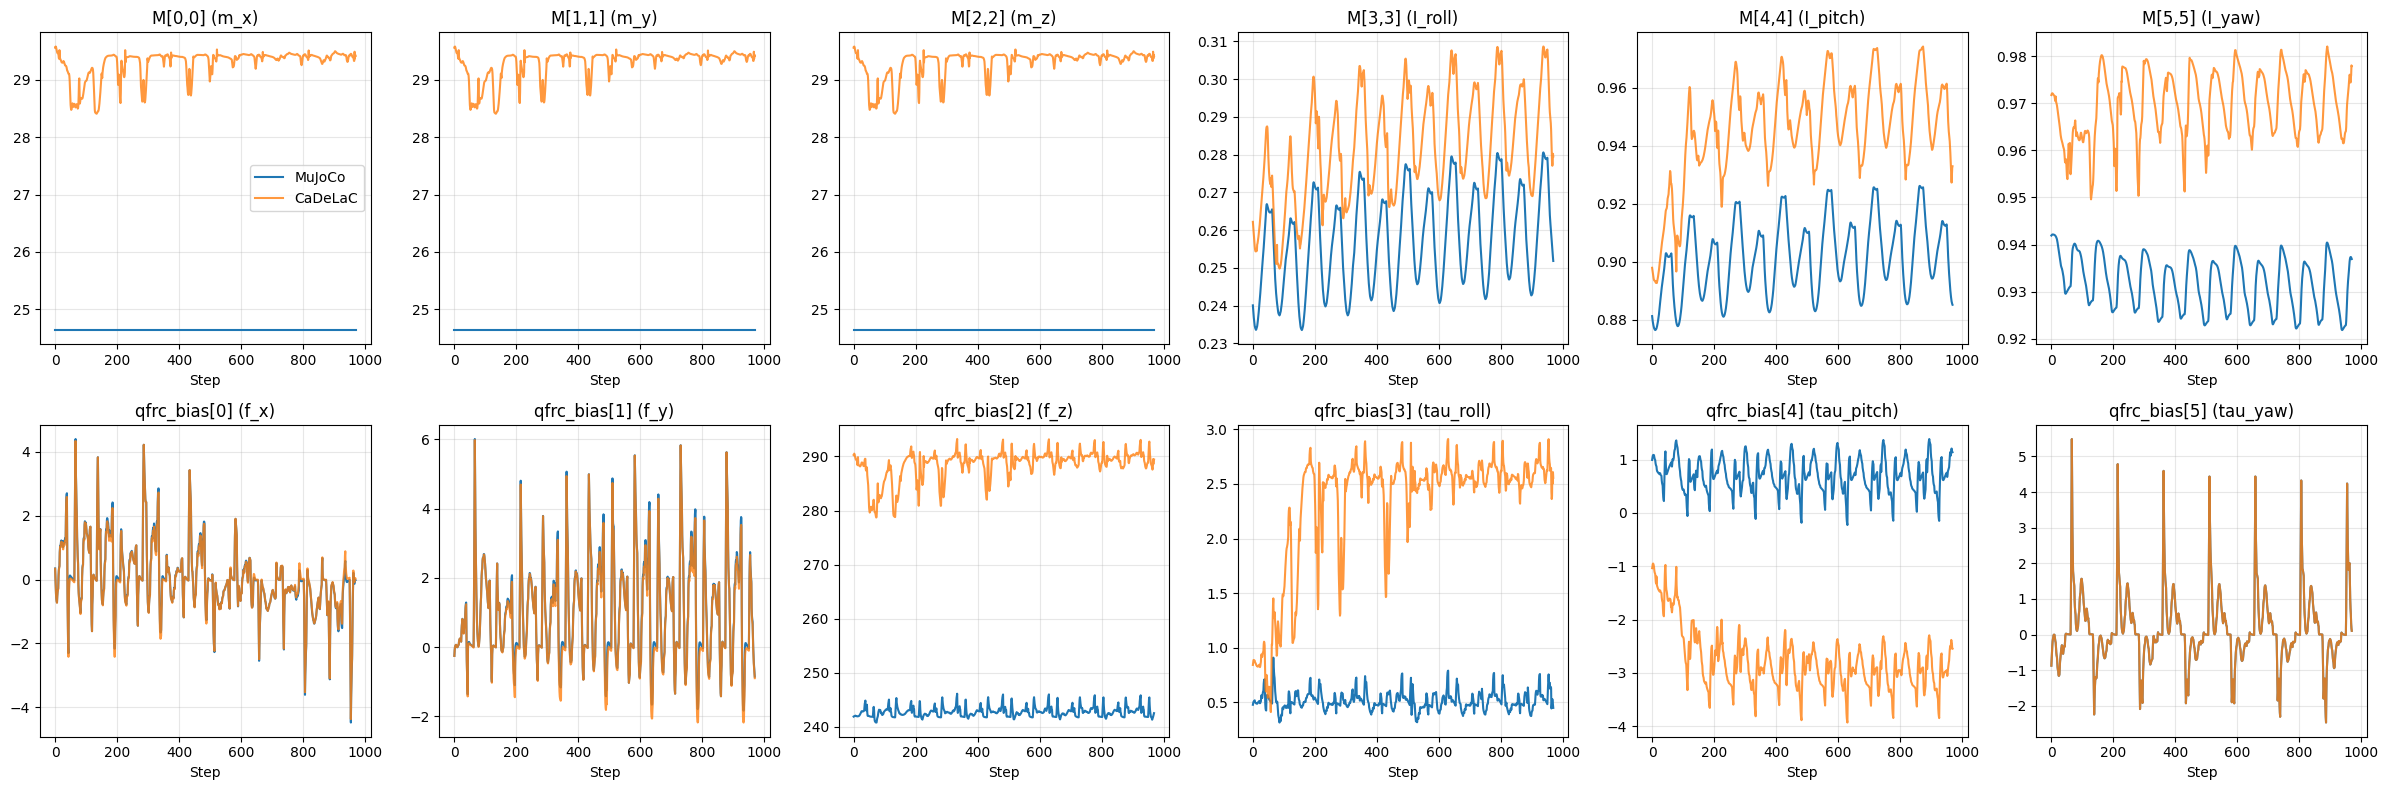

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 6, figsize=(24, 8))
diag_labels = ["m_x", "m_y", "m_z", "I_roll", "I_pitch", "I_yaw"]
qfrc_labels = ["f_x", "f_y", "f_z", "tau_roll", "tau_pitch", "tau_yaw"]

# Obere Reihe: Inertia-Diagonalen
for i in range(6):
    ax = axes[0, i]
    ax.plot(M_diag_mj[:, i], label="MuJoCo", color="tab:blue", linewidth=1.5)
    ax.plot(M_diag_cd[:, i], label="CaDeLaC", color="tab:orange", linewidth=1.5, alpha=0.8)
    ax.set_title(f"M[{i},{i}] ({diag_labels[i]})")
    ax.set_xlabel("Step")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend()

# Untere Reihe: qfrc_bias-Komponenten
for i in range(6):
    ax = axes[1, i]
    ax.plot(qfrc_mj[:, i], label="MuJoCo", color="tab:blue", linewidth=1.5)
    ax.plot(qfrc_cd[:, i], label="CaDeLaC", color="tab:orange", linewidth=1.5, alpha=0.8)
    ax.set_title(f"qfrc_bias[{i}] ({qfrc_labels[i]})")
    ax.set_xlabel("Step")
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("cadelac_vs_mujoco.png", dpi=100)
plt.show()